# 00 — Setup and correctness gates

This notebook records the mandatory pod preflight, validates the official J-Lens adapter against Hugging Face, tests the known spider→8 / ant→6 intervention, and compares first-order attribution predictions with real residual ablations. The signed convention is always $\Delta M=M_{edited}-M_{clean}$. A failed gate is recorded plainly; G3 is diagnostic rather than permission to trust downstream 7B claims if strict G2 fails.

In [1]:
import os
import subprocess
from pathlib import Path

ROOT = Path('/home/jovyan/j-space-thoughts')
os.chdir(ROOT)
os.environ['PATH'] = f"{Path.home()}/.local/bin:{Path.home()}/.npm-global/bin:{os.environ['PATH']}"
os.environ['PIP_USER'] = 'false'
os.environ['PYTHONNOUSERSITE'] = '1'
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
preflight = r'''
set -e
echo "$PATH"
command -v codex; command -v hf
codex --version
hf auth whoami
git -C ~/j-space-thoughts config --global --list
git -C ~/j-space-thoughts remote -v
nvidia-smi
'''
completed = subprocess.run(preflight, shell=True, executable='/bin/bash', text=True, capture_output=True)
print(completed.stdout)
if completed.stderr:
    print(completed.stderr)
assert completed.returncode == 0, f'PREFLIGHT FAIL: return code {completed.returncode}'
assert 'origin' in completed.stdout, 'PREFLIGHT FAIL: Git origin missing'
print('PREFLIGHT PASS')

/home/jovyan/.local/bin:/home/jovyan/.npm-global/bin:/command:/opt/rsync/usr/bin:/opt/ssh/usr/bin:/opt/ssh/usr/sbin:/opt/sudo/usr/bin:/opt/sudo/usr/sbin:/opt/conda/bin:/opt/conda/condabin:/opt/conda/bin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin
/home/jovyan/.npm-global/bin/codex
/home/jovyan/.local/bin/hf
codex-cli 0.142.5
user=sushmanth orgs=devoworm-group,sushmanthreddy,OWG,syscv-community,context-course
user.name=sushmanthreddy
user.email=sushmanthreddymereddy@cisco.com
init.defaultbranch=main
credential.helper=store --file /home/jovyan/.git-credentials
origin	https://github.com/sushmanthreddy/j-space-thoughts.git (fetch)
origin	https://github.com/sushmanthreddy/j-space-thoughts.git (push)
Tue Jul  7 05:35:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.163.01             Driver Version: 550.163.01     CUDA Version: 12.4     |
|-----------------------------------------+--------------------

In [2]:
import sys

for label, path in [('project', ROOT / 'tests'), ('upstream J-Lens', Path.home() / 'deps/jacobian-lens/tests')]:
    test_run = subprocess.run([sys.executable, '-m', 'pytest', '-q', '-p', 'no:cacheprovider', str(path)], text=True, capture_output=True)
    print(f'[{label}]')
    print(test_run.stdout)
    if test_run.stderr:
        print(test_run.stderr)
    assert test_run.returncode == 0, f'{label} tests failed'
print('METHOD UNIT TESTS PASS')

[project]
............                                                             [100%]
12 passed in 9.71s



[upstream J-Lens]
................................                                         [100%]
32 passed in 2.07s

METHOD UNIT TESTS PASS


## Gate protocol

- **G1:** mean KL below $10^{-3}$ on every one of 20 prompts; every prompt token is compared.
- **G2 strict:** clean top-1 is `8`, spider reaches J-Lens rank ≤10, and an $\alpha=1$ clean-clamped spider/ant swap over the preregistered 40–90% band makes `6` top-1. The Qwen RMSNorm-gain-folded, rank-equivalent direction is the implementation-correct swap; raw $W_UJ$ is retained as a sensitivity.
- **G3:** on a seeded clean/token-valid two-hop subset, report Pearson correlation and a paired bootstrap 95% CI between $-\sum WRITE\,READ$ and real ablation $\Delta M$. Reliability is an outcome, not a condition silently optimized to pass.

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

G1 PASS: N=20, max mean KL=1.66e-08, max position KL=1.5e-07


G2 FAIL (directional subgate PASS): min spider rank=1, clean M=6.500, swap M=-1.000, swapped top='4'
G2 failure documented: Qwen-7B does not reproduce the strict known-answer top-1 swap under the preregistered band. Downstream 7B results are diagnostic.


/opt/conda/lib/python3.11/site-packages/torch/autograd/graph.py:825: UserWarning: Flash Attention defaults to a non-deterministic algorithm. To explicitly enable determinism call torch.use_deterministic_algorithms(True, warn_only=False). (Triggered internally at ../aten/src/ATen/native/transformers/cuda/attention_backward.cu:102.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


G3 01/20 animal-legs-buffalo2: pred=1.494, actual=0.438
G3 02/20 basketball-players: pred=-0.983, actual=-4.125


...

G3 13/20 ex2-city-capital-Osaka: pred=5.505, actual=-1.625
G3 14/20 ex2-language-capital-Hungarian: pred=-3.422, actual=-2.812


G3 15/20 ex2-river-capital-Thames: pred=6.041, actual=-0.375
G3 16/20 food-animal-butter: pred=6.667, actual=2.125


G3 17/20 func-pumps-chambers: pred=-0.830, actual=0.875
G3 18/20 instr-body-trumpet: pred=-7.177, actual=-1.500


G3 19/20 organ-count-kidney2: pred=7.121, actual=0.938
G3 20/20 person-firstname-mozart: pred=-5.409, actual=-5.695


G3 PASS (computed): N=20, r=-0.360 95% CI [-0.736, 0.330], attribution_reliable=False
Saved raw gates: /home/jovyan/j-space-thoughts/data/raw/00_gates_qwen7b.json
Saved curated metrics: /home/jovyan/j-space-thoughts/results/metrics.json


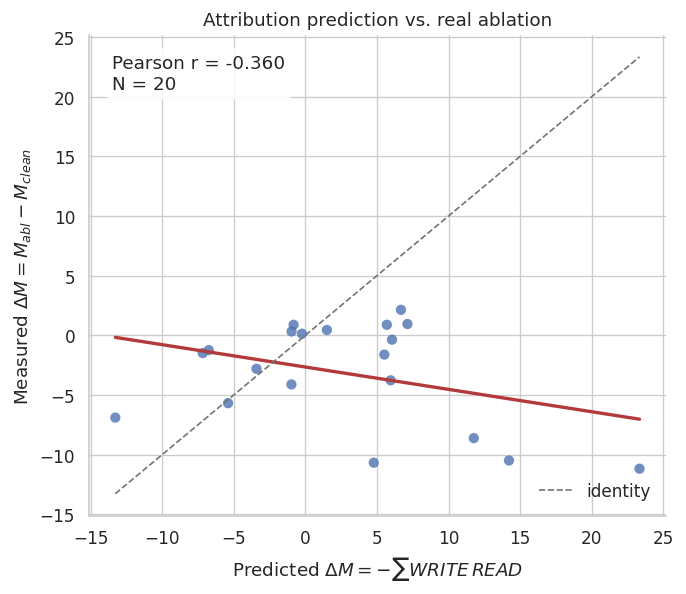

In [3]:
from src.gates import run_all_gates

payload = run_all_gates()

In [4]:
import pandas as pd

gates = payload['gates']
display(pd.DataFrame([
    {'gate': 'G1 logits', 'status': gates['g1']['status'], 'N': gates['g1']['n'], 'result': gates['g1']['max_prompt_mean_kl']},
    {'gate': 'G2 spider strict', 'status': gates['g2']['status'], 'N': 1, 'result': gates['g2']['variants']['swap_rms_gain_folded']['delta']},
    {'gate': 'G2 directional', 'status': gates['g2']['directional_subgate'], 'N': 1, 'result': gates['g2']['variants']['swap_rms_gain_folded']['metric']},
    {'gate': 'G3 validation computed', 'status': gates['g3']['status'], 'N': gates['g3']['n'], 'result': gates['g3']['correlation']['estimate']},
]))
print('G3 95% bootstrap CI:', gates['g3']['correlation']['ci_low'], gates['g3']['correlation']['ci_high'])
print('Attribution reliable under preregistered rule:', gates['g3']['attribution_reliable'])

,gate,status,N,result
0,G1 logits,PASS,20,1.660217e-08
1,G2 spider strict,FAIL,1,-7.500000e+00
2,G2 directional,PASS,1,-1.000000e+00
3,G3 validation computed,PASS,20,-3.596712e-01


G3 95% bootstrap CI: -0.7360027114660479 0.3295164259924125
Attribution reliable under preregistered rule: False


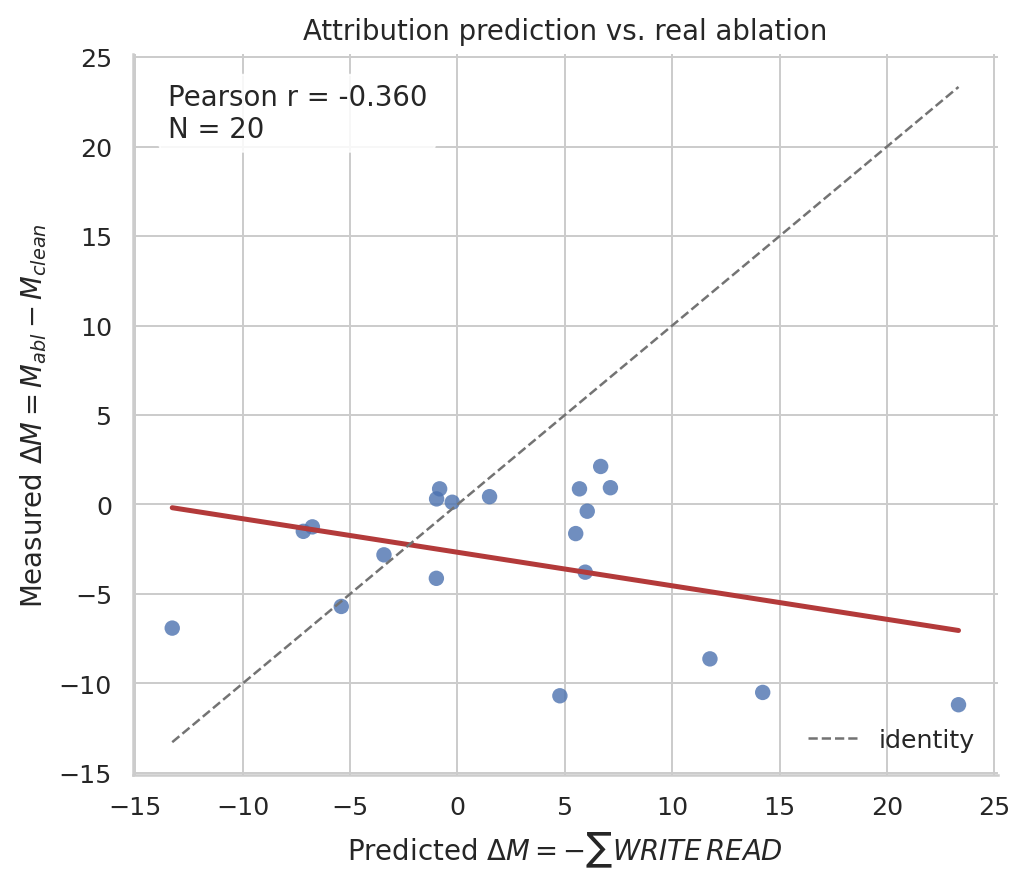

In [5]:
from IPython.display import Image, display

display(Image(filename=str(ROOT / gates['g3']['figure'])))

In [6]:
print('PHASE 00 STATUS')
print('  Preflight: PASS')
print('  G1:', gates['g1']['status'])
print('  G2 strict:', gates['g2']['status'])
print('  G2 target-vs-foil directional subgate:', gates['g2']['directional_subgate'])
print('  G3 computation:', gates['g3']['status'])
if gates['g2']['status'] != 'PASS':
    print('  OVERALL: FAIL for a strict usable 7B workspace; downstream 7B analyses are diagnostic only.')
else:
    print('  OVERALL: PASS')

PHASE 00 STATUS
  Preflight: PASS
  G1: PASS
  G2 strict: FAIL
  G2 target-vs-foil directional subgate: PASS
  G3 computation: PASS
  OVERALL: FAIL for a strict usable 7B workspace; downstream 7B analyses are diagnostic only.
